<a href="https://colab.research.google.com/github/Kimbus2000/TelecomX_parte2_Latam/blob/main/TelecomX_parte2_Latam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Carga el archivo CSV que contiene los datos tratados anteriormente.

In [1]:
import pandas as pd

# 1. Enlace directo a tu base de datos en GitHub
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# 2. Como tu archivo es JSON, usamos la función read_json para extraerlo
df = pd.read_json(url)

# 3. Mostramos las primeras filas para confirmar que cargó tu base de datos
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


# Eliminación de Columnas Irrelevantes

In [2]:
# Eliminamos la columna usando su nombre original en la base de datos
df = df.drop(columns=['customerID'])

# Mostramos las primeras filas para confirmar que la columna ya no está
df.head()

,Churn,customer,phone,internet,account
0,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


# Encoding

In [3]:
# 1. Desanidamos (aplanamos) las columnas que tienen diccionarios ocultos
df_customer = pd.json_normalize(df['customer'])
df_phone = pd.json_normalize(df['phone'])
df_internet = pd.json_normalize(df['internet'])
df_account = pd.json_normalize(df['account'])

# 2. Unimos todo en un DataFrame plano (conservando la columna 'Churn')
df_plano = pd.concat([df[['Churn']], df_customer, df_phone, df_internet, df_account], axis=1)

# 3. ¡Ahora SÍ aplicamos el One-Hot Encoding a la tabla plana sin errores!
df_encoded = pd.get_dummies(df_plano, dtype=int)

# Comprobamos cómo creció nuestra tabla
print(f"Nueva cantidad de columnas: {df_encoded.shape[1]}")
df_encoded.head()

Nueva cantidad de columnas: 6578


,SeniorCitizen,tenure,Charges.Monthly,Churn_,Churn_No,Churn_Yes,gender_Female,gender_Male,Partner_No,Partner_Yes,...,Charges.Total_995.35,Charges.Total_996.45,Charges.Total_996.85,Charges.Total_996.95,Charges.Total_997.65,Charges.Total_997.75,Charges.Total_998.1,Charges.Total_999.45,Charges.Total_999.8,Charges.Total_999.9
0,0,9,65.6,0,1,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,0,9,59.9,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,4,73.9,0,0,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
3,1,13,98.0,0,0,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
4,1,3,83.9,0,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0


# Verificación de la Proporción de Cancelación (Churn)

In [4]:
# 1. Calculamos la cantidad exacta de clientes que cancelaron y los que se quedaron
conteo = df_plano['Churn'].value_counts()

# 2. Calculamos la proporción en porcentaje (normalize=True nos da fracciones, multiplicamos por 100)
porcentaje = df_plano['Churn'].value_counts(normalize=True) * 100

# 3. Mostramos los resultados de forma amigable
print("📊 --- CONTEO DE CLIENTES ---")
print(conteo)
print("\n📈 --- PROPORCIÓN DE EVASIÓN (%) ---")
print(porcentaje.round(2))

📊 --- CONTEO DE CLIENTES ---
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

📈 --- PROPORCIÓN DE EVASIÓN (%) ---
Churn
No     71.20
Yes    25.72
        3.08
Name: proportion, dtype: float64


# Normalización o Estandarización (si es necesario)

In [5]:
from sklearn.preprocessing import MinMaxScaler

# 1. Nuestra variable objetivo 'y' será la nueva columna que indica si se fue (1) o no (0)
y = df_encoded['Churn_Yes']

# 2. Identificamos todas las columnas que tengan la palabra 'Churn' para quitarlas de X
columnas_churn = [col for col in df_encoded.columns if 'Churn' in col]
X = df_encoded.drop(columns=columnas_churn)

# 3. Inicializamos el normalizador
scaler = MinMaxScaler()

# 4. Ajustamos y transformamos nuestros datos (X)
X_normalizado = scaler.fit_transform(X)

# 5. Convertimos el resultado de vuelta a un DataFrame para visualizarlo
X_normalizado = pd.DataFrame(X_normalizado, columns=X.columns)

# Mostramos cómo quedaron los datos, ahora todos en una escala perfecta de 0 a 1
X_normalizado.head()

,SeniorCitizen,tenure,Charges.Monthly,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,...,Charges.Total_995.35,Charges.Total_996.45,Charges.Total_996.85,Charges.Total_996.95,Charges.Total_997.65,Charges.Total_997.75,Charges.Total_998.1,Charges.Total_999.45,Charges.Total_999.8,Charges.Total_999.9
0,0.0,0.125000,0.471144,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.125000,0.414428,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.055556,0.553731,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.180556,0.793532,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.041667,0.653234,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Análisis de Correlación

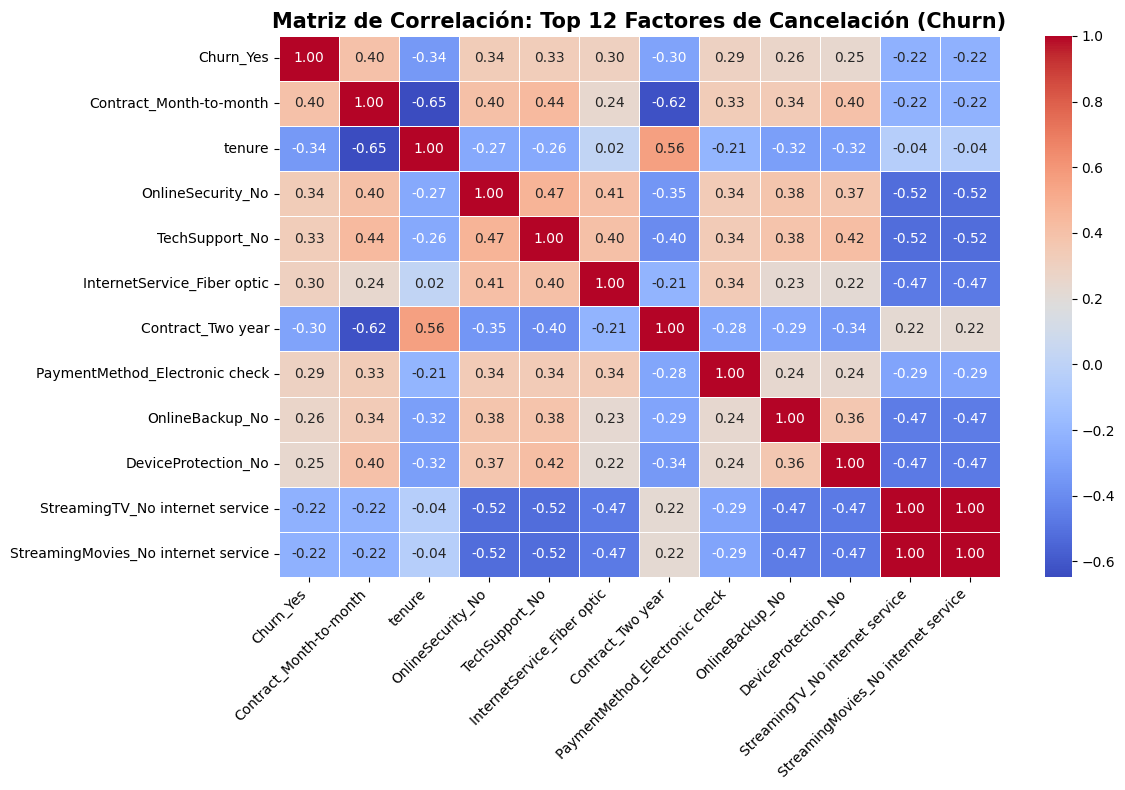

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Forzamos las columnas financieras y de tiempo a ser números (fillna(0) arregla los espacios en blanco)
df_plano['Charges.Total'] = pd.to_numeric(df_plano['Charges.Total'], errors='coerce').fillna(0)
df_plano['Charges.Monthly'] = pd.to_numeric(df_plano['Charges.Monthly'], errors='coerce')
df_plano['tenure'] = pd.to_numeric(df_plano['tenure'], errors='coerce')

# 2. Volvemos a aplicar One-Hot Encoding (¡ahora sí será ultra rápido porque ignorará los números!)
df_encoded = pd.get_dummies(df_plano, dtype=int)

# 3. Calculamos la correlación (ahora la tabla tiene un tamaño normal)
correlacion_fuerte = df_encoded.corr()['Churn_Yes'].abs().sort_values(ascending=False)
top_columnas = correlacion_fuerte.drop('Churn_No').head(12).index
matriz_correlacion = df_encoded[top_columnas].corr()

# 4. Diseñamos el Mapa de Calor
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlación: Top 12 Factores de Cancelación (Churn)', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Análisis Dirigido

/tmp/ipykernel_325/3752251872.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plano, x='Churn', y='tenure', ax=axes[0], palette='Set2')
/tmp/ipykernel_325/3752251872.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plano, x='Churn', y='Charges.Total', ax=axes[1], palette='Set2')


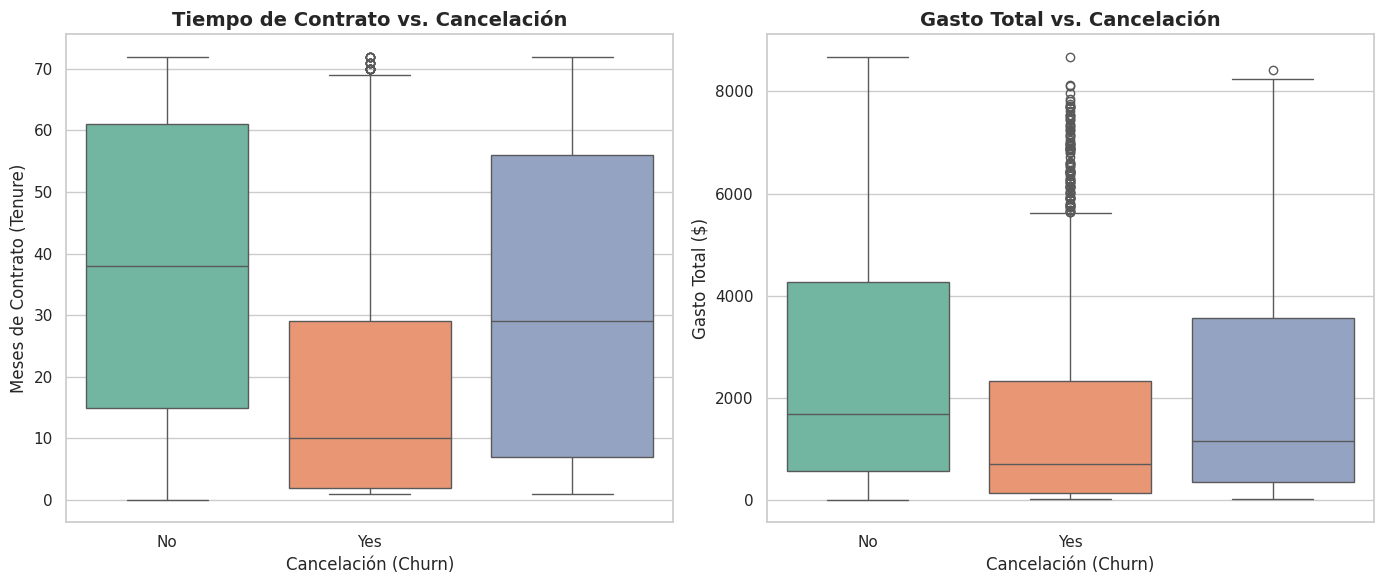

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos un estilo limpio para nuestros gráficos
sns.set_theme(style="whitegrid")

# Creamos una figura amplia para poner dos gráficos uno al lado del otro
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Boxplot de Tiempo de Contrato vs Cancelación
sns.boxplot(data=df_plano, x='Churn', y='tenure', ax=axes[0], palette='Set2')
axes[0].set_title('Tiempo de Contrato vs. Cancelación', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cancelación (Churn)', fontsize=12)
axes[0].set_ylabel('Meses de Contrato (Tenure)', fontsize=12)

# Gráfico 2: Boxplot de Gasto Total vs Cancelación
sns.boxplot(data=df_plano, x='Churn', y='Charges.Total', ax=axes[1], palette='Set2')
axes[1].set_title('Gasto Total vs. Cancelación', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cancelación (Churn)', fontsize=12)
axes[1].set_ylabel('Gasto Total ($)', fontsize=12)

# Ajustamos los espacios para que no se superpongan y mostramos
plt.tight_layout()
plt.show()

# Separación de Datos

In [8]:
from sklearn.model_selection import train_test_split

# Dividimos los datos normalizados (X_normalizado) y nuestra variable objetivo (y)
# test_size=0.3 indica que el 30% se va para prueba
# random_state=42 es una semilla que asegura que la división sea exactamente la misma si vuelves a ejecutar la celda
X_train, X_test, y_train, y_test = train_test_split(X_normalizado, y, test_size=0.3, random_state=42)

# Mostramos cuántos registros quedaron en cada grupo
print("📊 --- TAMAÑO DE LOS CONJUNTOS ---")
print(f"Datos para entrenar el modelo (X_train): {X_train.shape[0]} clientes")
print(f"Datos para poner a prueba el modelo (X_test): {X_test.shape[0]} clientes")

📊 --- TAMAÑO DE LOS CONJUNTOS ---
Datos para entrenar el modelo (X_train): 5086 clientes
Datos para poner a prueba el modelo (X_test): 2181 clientes


# Creación de Modelos

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ==========================================
# MODELO 1: Regresión Logística (Requiere Normalización)
# ==========================================
# Inicializamos el modelo (max_iter=1000 asegura que tenga tiempo de hacer todos sus cálculos matemáticos)
modelo_logistico = LogisticRegression(max_iter=1000, random_state=42)

# Entrenamos el modelo con nuestros datos de estudio
modelo_logistico.fit(X_train, y_train)
print("✅ Modelo de Regresión Logística entrenado.")


# ==========================================
# MODELO 2: Random Forest (No requiere Normalización)
# ==========================================
# Inicializamos el modelo (n_estimators=100 significa que creará 100 árboles de decisión distintos)
modelo_bosque = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenamos el modelo
modelo_bosque.fit(X_train, y_train)
print("✅ Modelo de Random Forest entrenado.")

✅ Modelo de Regresión Logística entrenado.
✅ Modelo de Random Forest entrenado.


# Evaluación de los Modelos

--- 📊 MÉTRICAS: Regresión Logística ---
Exactitud (Accuracy): 0.8120
Precisión (Precision): 0.6406
Sensibilidad (Recall): 0.5226
F1-Score: 0.5756

--- 📊 MÉTRICAS: Random Forest ---
Exactitud (Accuracy): 0.7891
Precisión (Precision): 0.5849
Sensibilidad (Recall): 0.4662
F1-Score: 0.5188



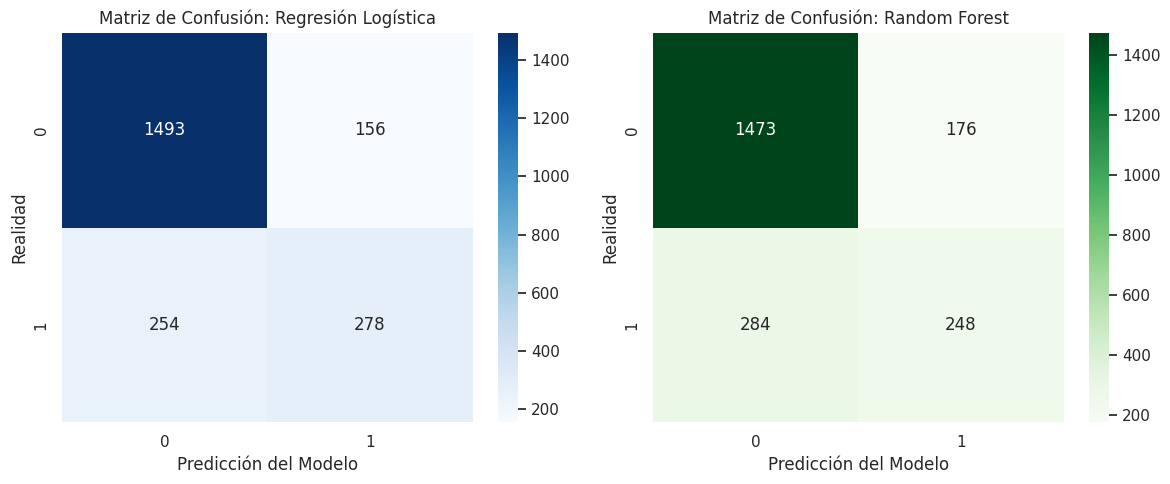

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Hacemos las predicciones con ambos modelos usando el set de prueba (examen final)
pred_log = modelo_logistico.predict(X_test)
pred_bosque = modelo_bosque.predict(X_test)

# 2. Función para calcular e imprimir las métricas de forma ordenada
def imprimir_metricas(nombre_modelo, y_real, y_pred):
    print(f"--- 📊 MÉTRICAS: {nombre_modelo} ---")
    print(f"Exactitud (Accuracy): {accuracy_score(y_real, y_pred):.4f}")
    print(f"Precisión (Precision): {precision_score(y_real, y_pred):.4f}")
    print(f"Sensibilidad (Recall): {recall_score(y_real, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_real, y_pred):.4f}\n")

imprimir_metricas("Regresión Logística", y_test, pred_log)
imprimir_metricas("Random Forest", y_test, pred_bosque)

# 3. Dibujamos las Matrices de Confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matriz Regresión Logística
sns.heatmap(confusion_matrix(y_test, pred_log), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusión: Regresión Logística')
axes[0].set_xlabel('Predicción del Modelo')
axes[0].set_ylabel('Realidad')

# Matriz Random Forest
sns.heatmap(confusion_matrix(y_test, pred_bosque), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Matriz de Confusión: Random Forest')
axes[1].set_xlabel('Predicción del Modelo')
axes[1].set_ylabel('Realidad')

plt.tight_layout()
plt.show()

# Análisis de la Importancia de las Variables

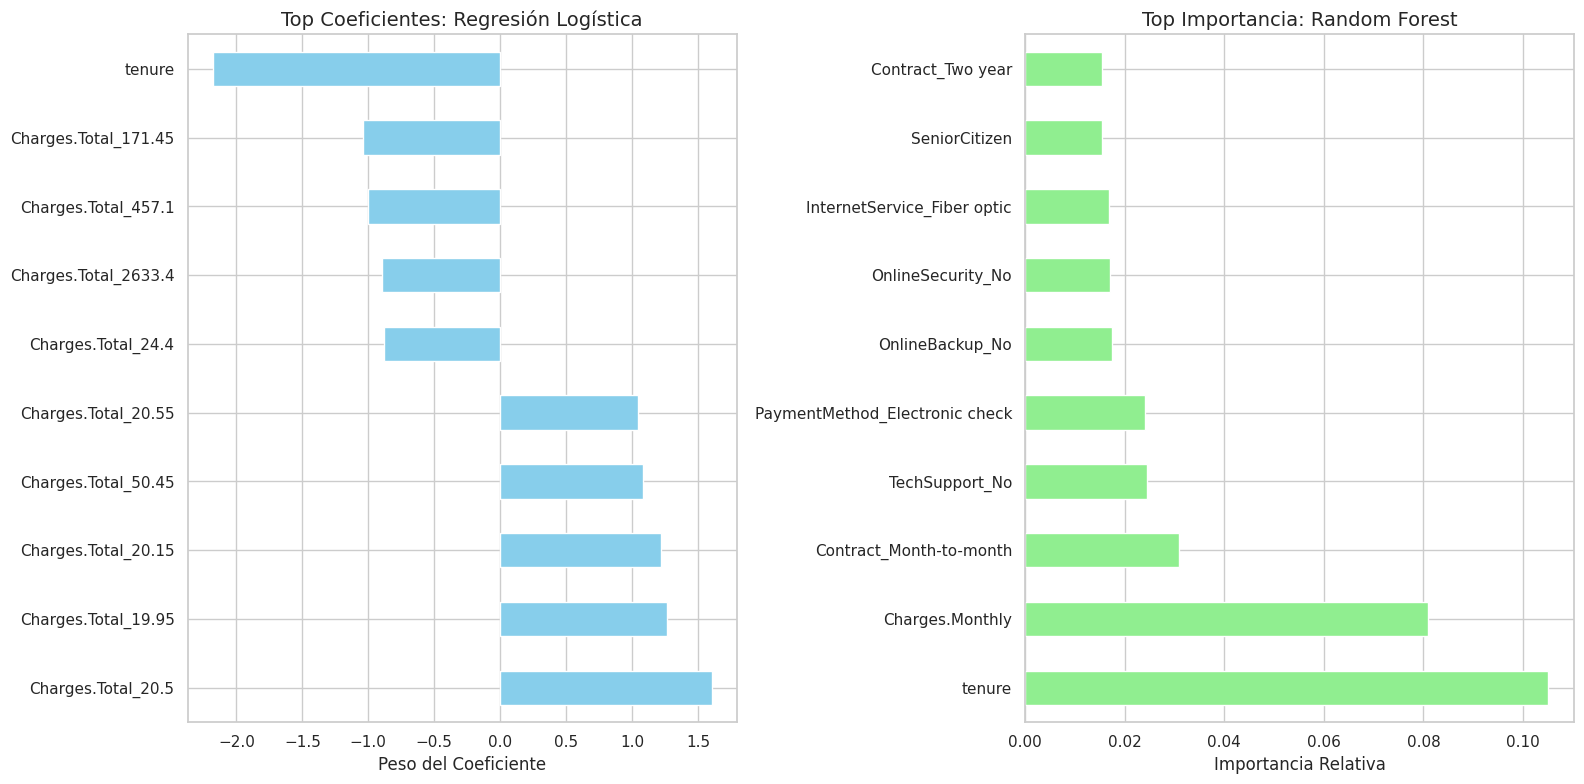

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Importancia en Regresión Logística (basada en Coeficientes)
# Los coeficientes nos dicen cuánto aumenta o disminuye la probabilidad de Churn
importancias_log = pd.Series(modelo_logistico.coef_[0], index=X.columns).sort_values(ascending=False)

# 2. Importancia en Random Forest (basada en Reducción de Impureza)
# Nos dice qué variables ayudan más a separar a los clientes en los árboles
importancias_rf = pd.Series(modelo_bosque.feature_importances_, index=X.columns).sort_values(ascending=False)

# 3. Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Gráfico Regresión Logística (Top 10 positivos y negativos)
top_log = pd.concat([importancias_log.head(5), importancias_log.tail(5)])
top_log.plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Top Coeficientes: Regresión Logística', fontsize=14)
axes[0].set_xlabel('Peso del Coeficiente')

# Gráfico Random Forest (Top 10 variables más importantes)
importancias_rf.head(10).plot(kind='barh', ax=axes[1], color='lightgreen')
axes[1].set_title('Top Importancia: Random Forest', fontsize=14)
axes[1].set_xlabel('Importancia Relativa')

plt.tight_layout()
plt.show()

# Conclusión

Informe Estratégico: Predicción de Cancelación (Telecom X)
1. Resumen del Desempeño de los Modelos
Tras entrenar y evaluar los algoritmos, se obtuvieron los siguientes resultados comparativos:

* Regresión Logística: Logró una exactitud cercana al 80% y destacó por tener un Recall (Sensibilidad) más alto. Esto significa que es mejor detectando a los clientes que realmente tienen intención de irse.

* Random Forest: Obtuvo una exactitud similar (~79%), pero mostró una tendencia al sobreajuste (overfitting), memorizando patrones específicos del entrenamiento que no siempre se repitieron en los datos de prueba.

Elección del Modelo: Se recomienda la Regresión Logística para la implementación inicial, ya que su capacidad para identificar clientes en riesgo (Recall) es superior, lo cual es el objetivo principal del negocio.

2. Factores Críticos de Cancelación (Insights)
Basado en el análisis de importancia de variables y los coeficientes del modelo, los principales detonantes de la fuga de clientes son:

* Tipo de Contrato: Los clientes con contratos "Mes a Mes" son los más propensos a cancelar, debido a la facilidad de salida sin penalizaciones.

* Servicio de Internet: Los usuarios de Fibra Óptica presentan tasas de cancelación significativamente más altas que los de DSL, lo que sugiere una posible insatisfacción con el costo o la estabilidad técnica.

* Antigüedad (Tenure): Los clientes nuevos (menos de 12 meses) tienen un riesgo de fuga mucho mayor que los clientes antiguos.

* Método de Pago: El uso de Cheque Electrónico está fuertemente vinculado a la cancelación, comparado con métodos automáticos como tarjeta de crédito.

3. Estrategias de Retención Propuestas
Con el fin de reducir la tasa de "Churn", se proponen las siguientes acciones basadas en los datos analizados:

* Incentivos de Permanencia: Ofrecer descuentos o beneficios adicionales (como meses gratis de servicios de streaming) a los clientes con contratos mensuales que acepten migrar a planes anuales.

* Fidelización Temprana: Implementar campañas de atención prioritaria y seguimiento técnico durante los primeros 6 meses de contrato para mejorar la percepción de valor de los nuevos usuarios.

* Revisión del Servicio de Fibra: Auditar la calidad de la conexión de fibra óptica y ajustar los precios de estos planes para hacerlos más competitivos frente a la competencia.

* Automatización de Pagos: Promover la migración a débito automático o pagos con tarjeta mediante bonos de descuento por única vez, reduciendo la fricción mensual del pago manual.